### Price of a Bond over time

Consider a bond with face value F = 100 dollars maturing in five years, T = 5 with coupons of C = 10 dollars paid annually, the last one at maturity

Given the continuous compounding rate r = 12% find the price of the bond

Evaluate the price of the bond over time up until maturity

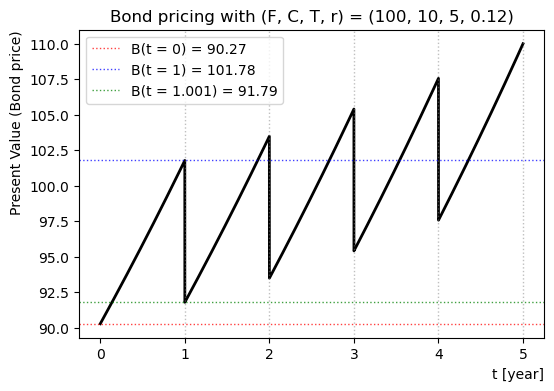

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def price(F, C, T, r, t):
    # Given a time t we can find how far from maturity the bond is 
    # and discount coupons and face accordingly
    B = 0
    # Discount remaining coupons 
    for i in range(1, T):
        if i < t: 
            pass
        else:
            B += C * np.exp(-r * (i - t))
    # Discount face value and final coupon
    B += (F + C) * np.exp(-r * (T - t))

    return B

F = 100
C = 10
T = 5
r = 0.12

times = np.linspace(0, T, 10000)
prices = [price(F, C, T, r, t) for t in times]

pv_0    = price(F, C, T, r, 0)
pv_1    = price(F, C, T, r, 1)
pv_1001 = price(F, C, T, r, 1.001)

fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.set_title(f'Bond pricing with (F, C, T, r) = ({F}, {C}, {T}, {r})')
ax.plot(times, prices, lw=2, color='black')
for t in range(1, T+1):
    ax.axvline(t, lw=1, ls=':', color='grey', alpha=0.5)

ax.axhline(pv_0, lw=1, ls=':', color='red', alpha=0.75, label=f'B(t = 0) = {round(pv_0, 2)}')
ax.axhline(pv_1, lw=1, ls=':', color='blue', alpha=0.75, label=f'B(t = 1) = {round(pv_1, 2)}')
ax.axhline(pv_1001, lw=1, ls=':', color='green', alpha=0.75, label=f'B(t = 1.001) = {round(pv_1001, 2)}')
#ax.set_xscale('log')
#ax.set_xlim(, 100)
ax.set_xlabel('t [year]', loc='right')
ax.set_ylabel('Present Value (Bond price)', loc='top')
ax.legend()
plt.show()


The plot shows us that each time a coupon is cashed, the Present Value decreases with a drop

The price drop corresponds to the coupon value ~C

- B(0) is the red line - Present value at time 0 when the bond is purchased
- B(1) is the blue line and corresponds to the value right before the coupon is paid ~ C above the green line
- B(1+) is the green line - Present value at time 1+, after the first coupon is cashed, hence after the drop

Each cycle:
1) Right after coupon 
	- Price is lower (coupon just paid, which translates into cash leaves the bond so its value decreases)
2) Time passes 
	- Price increases (discounting shrinks) 
3) Next coupon date 
	- Sudden drop again 

Giving the typical sawtooth shape